<a href="https://colab.research.google.com/github/nicecoconuts2/Evan_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [1]:
# write your answer here

from google.colab import files
uploaded = files.upload()

Saving bread_basket.csv to bread_basket (2).csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [4]:
# write your answer here
import pandas as pd

df = pd.read_csv("bread_basket (2).csv")
df.head()


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [5]:
# write your answer here

df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

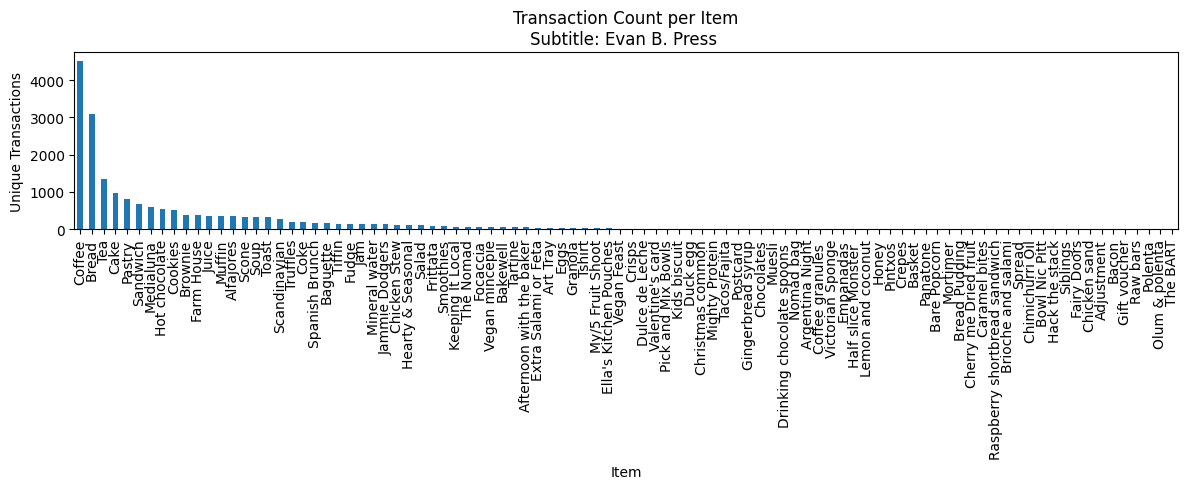

In [6]:
# c) Bar plot of transaction counts per item
import matplotlib.pyplot as plt

subtitle = "Evan B. Press "  # <-- EDIT THIS
item_counts = df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [7]:
# write your answer here

items_to_check = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

item_counts[items_to_check]

,transaction
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [14]:
# write your answer here

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth



transactions = df.groupby('transaction')['item'].apply(list).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()



frequent_itemsets = fpgrowth(basket, min_support=0.2, use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False)

,support,itemsets
1,0.478394,(Coffee)
0,0.327205,(Bread)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [22]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # get rid of annoying warnings

from mlxtend.frequent_patterns import fpgrowth, association_rules

# step 1: FP-growth again with LOWER support so we get multi-item sets

frequent_itemsets_4 = fpgrowth(basket, min_support=0.005, use_colnames=True)

# step 2: Generate rules using confidence

rules = association_rules(frequent_itemsets_4, metric="confidence", min_threshold=0.3)

# sort and show report table columns

rules_sorted = rules.sort_values(by="confidence", ascending=False)
rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)




,antecedents,consequents,support,confidence,lift
26,(Keeping It Local),(Coffee),0.005388,0.809524,1.692169
30,(Toast),(Coffee),0.023666,0.704403,1.472431
32,(Salad),(Coffee),0.006550,0.626263,1.309094
2,"(Hot chocolate, Cake)",(Coffee),0.006867,0.601852,1.258067
34,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
10,(Medialuna),(Coffee),0.035182,0.569231,1.189878
7,(Pastry),(Coffee),0.047544,0.552147,1.154168
29,(Tiffin),(Coffee),0.008452,0.547945,1.145385
24,(Alfajores),(Coffee),0.019651,0.540698,1.130235
15,(Hearty & Seasonal),(Coffee),0.005705,0.540000,1.128777


In [25]:
#metrics for the rule Coffee, Cake => Bread computed directly from basket

A = basket['Coffee'] & basket['Cake']   # antecedent: coffee AND cake
B = basket['Bread']                     # consequent: bread

N = len(basket)



support = (A & B).sum() / N
confidence = (A & B).sum() / A.sum()
lift = confidence / (B.sum() / N)



print("support =", support)
print("confidence =", confidence)
print("lift =", lift)

support = 0.010036978341257264
confidence = 0.1833976833976834
lift = 0.5604969562024777


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

**Support:** With a support value of 0.0100, we can conclude that 1.00% of all transactions contain Coffee, Cake and Bread together.

> **Confidence:** With a confidence of 0.1834, we can conclude that 18.34% of customers who bought Coffee and Cake have also bought bread.

**Lift:**: (Lift < 1) With a lift value of 0.5605, being less than one. We can conclude a negative associaton. Any customer who buys Coffee and Cake are less likely to buy Bread compared to average customers. We can conclude that purchases of Coffee and Cake do not drive Bread purhcases.